# Finite-Well Tunneling and Variational Monte Carlo

Finite-well decay lengths, variational Monte Carlo for a quartic potential, and matching-method eigenstates of coupled wells.

Computational physics coursework by Udayan Sharma. Original code comments and saved outputs are retained. See the repository README for execution notes.


Representative well depth: V0 = 20.000
Bound states found:
  state 0: parity = even, E = 0.91826258
  state 1: parity = odd , E = 3.64773881
  state 2: parity = even, E = 8.09547070
  state 3: parity = odd , E = 14.00751589
  state 4: parity = even, E = 19.97874808


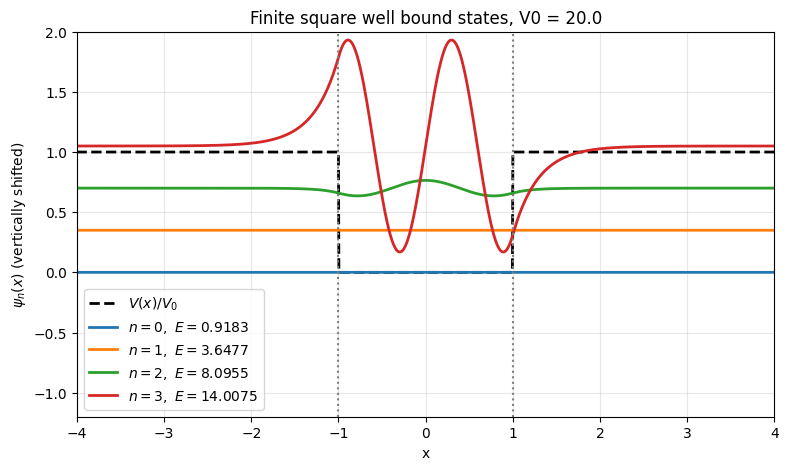

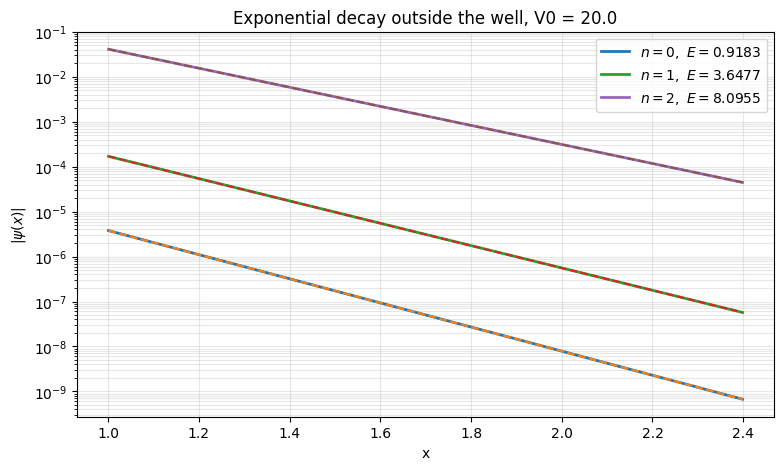


Decay-length data:

State n = 0
   V0        E_n         ell_fit      ell_theory   parity
  6.000     0.736012     0.308216     0.308196   even
  9.000     0.803508     0.247001     0.246985   even
 12.000     0.847729     0.211754     0.211740   even
 15.000     0.879811     0.188188     0.188176   even
 18.000     0.904561     0.171030     0.171019   even
 21.000     0.924459     0.157827     0.157816   even
 24.000     0.940938     0.147263     0.147253   even
 27.000     0.954896     0.138564     0.138555   even
 30.000     0.966929     0.131241     0.131232   even

State n = 1
   V0        E_n         ell_fit      ell_theory   parity
  6.000     2.840327     0.397824     0.397799   odd
  9.000     3.148416     0.292332     0.292313   odd
 12.000     3.344010     0.240356     0.240340   odd
 15.000     3.483306     0.208377     0.208363   odd
 18.000     3.589439     0.186283     0.186271   odd
 21.000     3.674003     0.169889     0.169878   odd
 24.000     3.743564     0.157120 

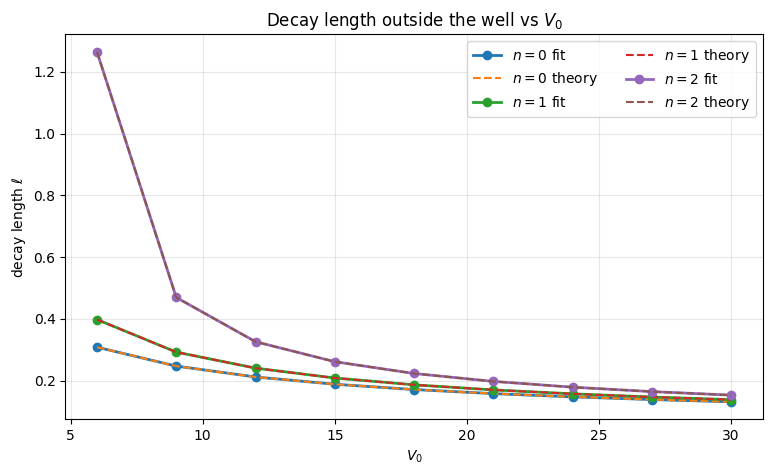

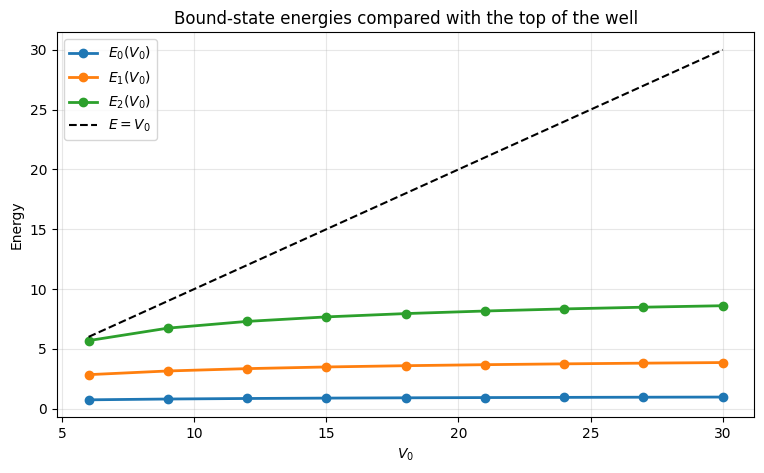


Numerical adequacy check at representative V0:

dx = 0.003
  n=0, parity=even, E=0.91706894, ell_fit=0.16185063, ell_th=0.16186854
  n=1, parity=odd , E=3.64304238, ell_fit=0.17481745, ell_th=0.17483716
  n=2, parity=even, E=8.08528353, ell_fit=0.20482961, ell_th=0.20485339

dx = 0.002
  n=0, parity=even, E=0.91944712, ell_fit=0.16187966, ell_th=0.16187863
  n=1, parity=odd , E=3.65239035, ell_fit=0.17488809, ell_th=0.17488714
  n=2, parity=even, E=8.10552940, ell_fit=0.20502847, ell_th=0.20502765

dx = 0.0015
  n=0, parity=even, E=0.91826258, ell_fit=0.16188431, ell_th=0.16187361
  n=1, parity=odd , E=3.64773881, ell_fit=0.17487373, ell_th=0.17486226
  n=2, parity=even, E=8.09547070, ell_fit=0.20495428, ell_th=0.20494102


In [ ]:
# ============================================================
# PHYS 580 / Computational Physics
# Homework 7 - Problem 1
# Finite square well via shooting method
#
# Study how the wavefunction outside the box depends on V0,
# verify exponential decay, and extract the decay length.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# ------------------------------------------------------------
# Problem setup
# ------------------------------------------------------------
a = 1.0                 # half-width of box, so well is |x| < a
xmax = 8.0              # outer boundary for shooting
dx = 0.0015             # main grid spacing
nscan = 500             # number of trial energies for bracketing roots

# Choose a representative set of well depths for the V0 study.
# Keep them large enough that at least the first few states exist.
V0_values = np.linspace(6.0, 30.0, 9)

# Representative V0 for detailed wavefunction/tail plots
V0_rep = 20.0

# ------------------------------------------------------------
# Potential
# ------------------------------------------------------------
def V_square(x, V0, a=1.0):
    x = np.asarray(x)
    return np.where(np.abs(x) < a, 0.0, V0)

# ------------------------------------------------------------
# Shooting on x >= 0 using parity
# ------------------------------------------------------------
def shoot_half(E, V0, parity='even', a=1.0, xmax=8.0, dx=0.0015):
    """
    Integrate from x = 0 to x = xmax using the recurrence
    psi_{i+1} = 2 psi_i - psi_{i-1} - 2 dx^2 (E - V_i) psi_i
    """
    N = int(round(xmax / dx))
    x = np.linspace(0.0, xmax, N + 1)
    V = np.where(x < a, 0.0, V0)

    psi = np.zeros(N + 1, dtype=float)

    if parity == 'even':
        # psi(0)=1, psi'(0)=0
        psi[0] = 1.0
        # Taylor start: psi(dx) = psi(0) + 0.5 psi''(0) dx^2
        # psi'' = 2(V-E) psi, and V(0)=0
        psi[1] = 1.0 - E * dx * dx
    elif parity == 'odd':
        # psi(0)=0, psi'(0)=1 (arbitrary scale)
        psi[0] = 0.0
        psi[1] = dx
    else:
        raise ValueError("parity must be 'even' or 'odd'")

    for i in range(1, N):
        psi[i + 1] = 2.0 * psi[i] - psi[i - 1] - 2.0 * dx * dx * (E - V[i]) * psi[i]

        # stop if the unphysical growing mode explodes numerically
        if abs(psi[i + 1]) > 1e80:
            psi[i + 1:] = np.nan
            break

    return x, psi

def residual(E, V0, parity='even', a=1.0, xmax=8.0, dx=0.0015):
    """
    Shooting residual: the value at the far boundary.
    Bound-state eigenvalues drive this close to zero.
    """
    x, psi = shoot_half(E, V0, parity=parity, a=a, xmax=xmax, dx=dx)
    return psi[-1]

# ------------------------------------------------------------
# Find bound-state energies for a given parity
# ------------------------------------------------------------
def find_roots_for_parity(V0, parity='even', a=1.0, xmax=8.0, dx=0.0015, nscan=500):
    """
    Scan E in (0, V0) and locate sign changes of the residual.
    """
    E_grid = np.linspace(1e-6, V0 - 1e-6, nscan)
    F_grid = np.array([residual(E, V0, parity=parity, a=a, xmax=xmax, dx=dx) for E in E_grid])

    roots = []
    for i in range(nscan - 1):
        f1 = F_grid[i]
        f2 = F_grid[i + 1]

        if not np.isfinite(f1) or not np.isfinite(f2):
            continue

        if f1 == 0.0 or f1 * f2 < 0.0:
            E1 = E_grid[i]
            E2 = E_grid[i + 1]

            try:
                root = brentq(
                    lambda E: residual(E, V0, parity=parity, a=a, xmax=xmax, dx=dx),
                    E1, E2, xtol=1e-13, rtol=1e-13, maxiter=300
                )
                if len(roots) == 0 or abs(root - roots[-1]) > 1e-6:
                    roots.append(root)
            except ValueError:
                pass

    return roots

def find_all_bound_states(V0, a=1.0, xmax=8.0, dx=0.0015, nscan=500):
    """
    Find even and odd bound states, then sort by energy.
    """
    even_roots = find_roots_for_parity(V0, parity='even', a=a, xmax=xmax, dx=dx, nscan=nscan)
    odd_roots  = find_roots_for_parity(V0, parity='odd',  a=a, xmax=xmax, dx=dx, nscan=nscan)

    states = []
    for E in even_roots:
        states.append(("even", E))
    for E in odd_roots:
        states.append(("odd", E))

    states.sort(key=lambda item: item[1])
    return states

# ------------------------------------------------------------
# Build full normalized wavefunction from half-line solution
# ------------------------------------------------------------
def full_wavefunction(E, V0, parity='even', a=1.0, xmax=8.0, dx=0.0015):
    xh, psih = shoot_half(E, V0, parity=parity, a=a, xmax=xmax, dx=dx)

    if parity == 'even':
        x_full   = np.concatenate((-xh[:0:-1], xh))
        psi_full = np.concatenate(( psih[:0:-1], psih))
    else:
        x_full   = np.concatenate((-xh[:0:-1], xh))
        psi_full = np.concatenate((-psih[:0:-1], psih))

    norm = np.sqrt(np.trapezoid(psi_full**2, x_full))
    psi_full /= norm

    return x_full, psi_full

# ------------------------------------------------------------
# Tail fit: ln |psi| = c - x/ell
# ------------------------------------------------------------
def fit_decay_length(x, psi, a=1.0):
    """
    Fit only the near-to-moderate exterior region, not the extreme far tail.
    This avoids roundoff contamination from a tiny growing component.
    """
    mask = (x > a + 0.05) & (x < a + 1.2)
    xx = x[mask]
    yy = np.abs(psi[mask])

    if len(xx) < 5:
        return np.nan, np.nan, np.nan

    # Keep values that are not too close to machine noise
    ymax = np.max(yy)
    use = (yy > ymax * 1e-4) & (yy < ymax * 0.95)

    xx = xx[use]
    yy = yy[use]

    if len(xx) < 5:
        return np.nan, np.nan, np.nan

    coeff = np.polyfit(xx, np.log(yy), 1)
    slope, intercept = coeff[0], coeff[1]

    if slope >= 0:
        return np.nan, slope, intercept

    ell_fit = -1.0 / slope
    return ell_fit, slope, intercept

# ------------------------------------------------------------
# Theoretical decay length
# ------------------------------------------------------------
def decay_length_theory(E, V0):
    if E >= V0:
        return np.nan
    return 1.0 / np.sqrt(2.0 * (V0 - E))

# ------------------------------------------------------------
# Get representative states
# ------------------------------------------------------------
states_rep = find_all_bound_states(V0_rep, a=a, xmax=xmax, dx=dx, nscan=nscan)

print(f"Representative well depth: V0 = {V0_rep:.3f}")
print("Bound states found:")
for i, (parity, E) in enumerate(states_rep):
    print(f"  state {i}: parity = {parity:4s}, E = {E:.8f}")

# ------------------------------------------------------------
# Plot 1: Representative wavefunctions and finite well
# ------------------------------------------------------------
plt.figure(figsize=(9, 5))

xplot = np.linspace(-xmax, xmax, 3000)
Vplot = V_square(xplot, V0_rep, a=a)

# Scale potential for overlay
plt.plot(xplot, Vplot / V0_rep, 'k--', lw=2, label=r'$V(x)/V_0$')

# Plot first few bound states
num_to_plot = min(4, len(states_rep))
for n in range(num_to_plot):
    parity, E = states_rep[n]
    x, psi = full_wavefunction(E, V0_rep, parity=parity, a=a, xmax=xmax, dx=dx)
    plt.plot(x, psi + 0.35*n, lw=2, label=fr'$n={n},\ E={E:.4f}$')

plt.axvline(-a, color='gray', ls=':', lw=1.5)
plt.axvline( a, color='gray', ls=':', lw=1.5)
plt.xlim(-4.0, 4.0)
plt.ylim(-1.2, 2.0)
plt.xlabel('x')
plt.ylabel(r'$\psi_n(x)$ (vertically shifted)')
plt.title(f'Finite square well bound states, V0 = {V0_rep}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ------------------------------------------------------------
# Plot 2: Semilog plot of tails to verify exponential decay
# ------------------------------------------------------------
plt.figure(figsize=(9, 5))

num_tail_plot = min(3, len(states_rep))
for n in range(num_tail_plot):
    parity, E = states_rep[n]
    x, psi = full_wavefunction(E, V0_rep, parity=parity, a=a, xmax=xmax, dx=dx)

    mask = (x > a) & (x < a + 1.4)
    xx = x[mask]
    yy = np.abs(psi[mask])

    plt.semilogy(xx, yy, lw=2, label=fr'$n={n},\ E={E:.4f}$')

    ell_fit, slope, intercept = fit_decay_length(x, psi, a=a)
    if np.isfinite(ell_fit):
        yy_fit = np.exp(intercept + slope * xx)
        plt.semilogy(xx, yy_fit, '--', lw=1.5)

plt.xlabel('x')
plt.ylabel(r'$|\psi(x)|$')
plt.title(f'Exponential decay outside the well, V0 = {V0_rep}')
plt.legend()
plt.grid(alpha=0.3, which='both')
plt.show()

# ------------------------------------------------------------
# Study decay length versus V0 for the first few states
# ------------------------------------------------------------
max_state_index = 2   # compare n = 0,1,2 where available

# Store results by state index
results = {n: {"V0": [], "E": [], "ell_fit": [], "ell_th": [], "parity": []}
           for n in range(max_state_index + 1)}

for V0 in V0_values:
    states = find_all_bound_states(V0, a=a, xmax=xmax, dx=dx, nscan=nscan)

    for n in range(min(len(states), max_state_index + 1)):
        parity, E = states[n]
        x, psi = full_wavefunction(E, V0, parity=parity, a=a, xmax=xmax, dx=dx)
        ell_fit, _, _ = fit_decay_length(x, psi, a=a)
        ell_th = decay_length_theory(E, V0)

        if np.isfinite(ell_fit):
            results[n]["V0"].append(V0)
            results[n]["E"].append(E)
            results[n]["ell_fit"].append(ell_fit)
            results[n]["ell_th"].append(ell_th)
            results[n]["parity"].append(parity)

# Print a compact table
print("\nDecay-length data:")
for n in range(max_state_index + 1):
    print(f"\nState n = {n}")
    print("   V0        E_n         ell_fit      ell_theory   parity")
    for V0, E, ef, et, p in zip(results[n]["V0"], results[n]["E"],
                                results[n]["ell_fit"], results[n]["ell_th"],
                                results[n]["parity"]):
        print(f"{V0:7.3f}   {E:10.6f}   {ef:10.6f}   {et:10.6f}   {p}")

# ------------------------------------------------------------
# Plot 3: Decay length vs V0
# ------------------------------------------------------------
plt.figure(figsize=(9, 5))

for n in range(max_state_index + 1):
    if len(results[n]["V0"]) == 0:
        continue

    V0_arr = np.array(results[n]["V0"])
    ef_arr = np.array(results[n]["ell_fit"])
    et_arr = np.array(results[n]["ell_th"])

    plt.plot(V0_arr, ef_arr, 'o-', lw=2, label=fr'$n={n}$ fit')
    plt.plot(V0_arr, et_arr, '--', lw=1.5, label=fr'$n={n}$ theory')

plt.xlabel(r'$V_0$')
plt.ylabel(r'decay length $\ell$')
plt.title('Decay length outside the well vs $V_0$')
plt.legend(ncol=2)
plt.grid(alpha=0.3)
plt.show()

# ------------------------------------------------------------
# Plot 4: Energy levels vs V0
# ------------------------------------------------------------
plt.figure(figsize=(9, 5))

for n in range(max_state_index + 1):
    if len(results[n]["V0"]) == 0:
        continue
    plt.plot(results[n]["V0"], results[n]["E"], 'o-', lw=2, label=fr'$E_{n}(V_0)$')

plt.plot(V0_values, V0_values, 'k--', lw=1.5, label=r'$E=V_0$')
plt.xlabel(r'$V_0$')
plt.ylabel(r'Energy')
plt.title('Bound-state energies compared with the top of the well')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ------------------------------------------------------------
# Numerical adequacy check: refine dx for representative V0
# ------------------------------------------------------------
print("\nNumerical adequacy check at representative V0:")
dx_list = [0.0030, 0.0020, 0.0015]

for dx_test in dx_list:
    states_test = find_all_bound_states(V0_rep, a=a, xmax=xmax, dx=dx_test, nscan=450)
    print(f"\ndx = {dx_test}")
    for n in range(min(3, len(states_test))):
        parity, E = states_test[n]
        x, psi = full_wavefunction(E, V0_rep, parity=parity, a=a, xmax=xmax, dx=dx_test)
        ell_fit, _, _ = fit_decay_length(x, psi, a=a)
        ell_th = decay_length_theory(E, V0_rep)
        print(f"  n={n}, parity={parity:4s}, E={E:.8f}, ell_fit={ell_fit:.8f}, ell_th={ell_th:.8f}")

In [ ]:
# Problem 1 Snippets

# Potential
def V_square(x, V0, a = 1.0):
    x = np.asarray(x);
    return np.where(np.abs(x) < a, 0.0, V0);

# Shooting on x >= 0 using parity.  Integrate from x = 0 to x = xmax using the recurrence
def shoot_half(E, V0, parity = 'even', a = 1.0, xmax = 8.0, dx = 0.0015):
    N = int(round(xmax / dx));
    x = np.linspace(0.0, xmax, N + 1);
    V = np.where(x < a, 0.0, V0);
    psi = np.zeros(N + 1, dtype = float);

    if parity == 'even':
        psi[0] = 1.0;
        psi[1] = 1.0 - E * dx * dx;
    elif parity == 'odd':
        psi[0] = 0.0;
        psi[1] = dx;
    else:
        raise ValueError("parity must be 'even' or 'odd'");

    for i in range(1, N):
        psi[i + 1] = 2.0 * psi[i] - psi[i - 1] - 2.0 * dx * dx * (E - V[i]) * psi[i];

        # stop if the unphysical growing mode explodes numerically
        if abs(psi[i + 1]) > 1e80:
            psi[i + 1:] = np.nan;
            break;

    return x, psi;

# Shooting residual: the value at the far boundary. Bound-state eigenvalues drive this close to zero.
def residual(E, V0, parity = 'even', a = 1.0, xmax = 8.0, dx = 0.0015):
    x, psi = shoot_half(E, V0, parity = parity, a = a , xmax = xmax, dx = dx);
    return psi[-1];

# Find bound-state energies for a given parity. Scan E in (0, V0) and locate sign changes of the residual.
def find_roots_for_parity(V0, parity = 'even', a = 1.0, xmax = 8.0, dx = 0.0015, nscan = 500):
    E_grid = np.linspace(1e-6, V0 - 1e-6, nscan);
    F_grid = np.array([residual(E, V0, parity = parity, a = a, xmax = xmax, dx = dx) for E in E_grid]);

    roots = [];
    for i in range(nscan - 1):
        f1 = F_grid[i];
        f2 = F_grid[i + 1];

        if not np.isfinite(f1) or not np.isfinite(f2):
            continue;

        if f1 == 0.0 or f1 * f2 < 0.0:
            E1 = E_grid[i];
            E2 = E_grid[i + 1];

            try:
                root = brentq(lambda E: residual(E, V0, parity = parity, a = a, xmax = xmax, dx = dx),
                              E1, E2, xtol = 1e-13, rtol = 1e-13, maxiter = 300);
                if len(roots) == 0 or abs(root - roots[-1]) > 1e-6:
                    roots.append(root);
            except ValueError:
                pass;

    return roots;

# Find even and odd bound states, then sort by energy.
def find_all_bound_states(V0, a = 1.0, xmax = 8.0, dx = 0.0015, nscan = 500):
    even_roots = find_roots_for_parity(V0, parity = 'even', a = a, xmax = xmax, dx = dx, nscan = nscan);
    odd_roots  = find_roots_for_parity(V0, parity = 'odd',  a = a, xmax = xmax, dx = dx, nscan = nscan);
    states = [];
    for E in even_roots:
        states.append(("even", E));
    for E in odd_roots:
        states.append(("odd", E));

    states.sort(key = lambda item: item[1]);
    return states;


# Build full normalized wavefunction from half-line solution
def full_wavefunction(E, V0, parity = 'even', a = 1.0, xmax = 8.0, dx = 0.0015):
    xh, psih = shoot_half(E, V0, parity = parity, a = a, xmax = xmax, dx = dx);
    if parity == 'even':
        x_full   = np.concatenate((-xh[:0:-1], xh));
        psi_full = np.concatenate(( psih[:0:-1], psih));
    else:
        x_full   = np.concatenate((-xh[:0:-1], xh));
        psi_full = np.concatenate((-psih[:0:-1], psih));

    norm = np.sqrt(np.trapezoid(psi_full**2, x_full));
    psi_full /= norm;

    return x_full, psi_full;

# Fit only the near-to-moderate exterior region, not the extreme far tail, avoiding roundoff contamination from a tiny growing component.
def fit_decay_length(x, psi, a = 1.0):
    mask = (x > a + 0.05) & (x < a + 1.2);
    xx = x[mask];
    yy = np.abs(psi[mask]);
    if len(xx) < 5:
        return np.nan, np.nan, np.nan;

    # Keep values that are not too close to machine noise
    ymax = np.max(yy);
    use = (yy > ymax * 1e-4) & (yy < ymax * 0.95);
    xx = xx[use];
    yy = yy[use];

    if len(xx) < 5:
        return np.nan, np.nan, np.nan;

    coeff = np.polyfit(xx, np.log(yy), 1);
    slope, intercept = coeff[0], coeff[1];
    if slope >= 0:
        return np.nan, slope, intercept;

    ell_fit = -1.0 / slope;
    return ell_fit, slope, intercept;


# Theoretical decay length
def decay_length_theory(E, V0):
    if E >= V0:
        return np.nan;
    return 1.0 / np.sqrt(2.0 * (V0 - E));


Starting coarse 2D scan over (alpha, beta)...

Best coarse result:
alpha_best = 0.650000
beta_best  = 0.140000
E_best     = 0.66755773 +/- 0.00030837
acceptance = 0.697

Starting refined 2D scan near the coarse minimum...

Best refined result:
alpha_opt(scan) = 0.72142857
beta_opt(scan)  = 0.10571429
E_opt(scan)     = 0.66780209 +/- 0.00010441
acceptance      = 0.723

Final optimized result:
alpha_opt = 0.72142857
beta_opt  = 0.10571429
E0(VMC)   = 0.66833843 +/- 0.00005660
acceptance fraction = 0.722


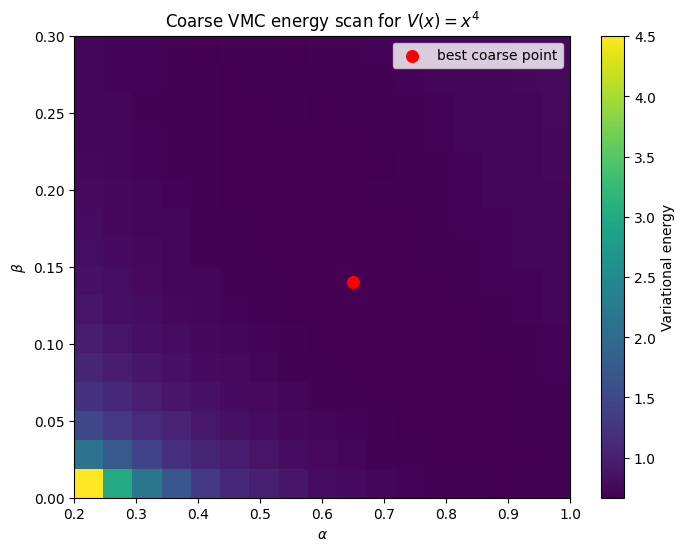

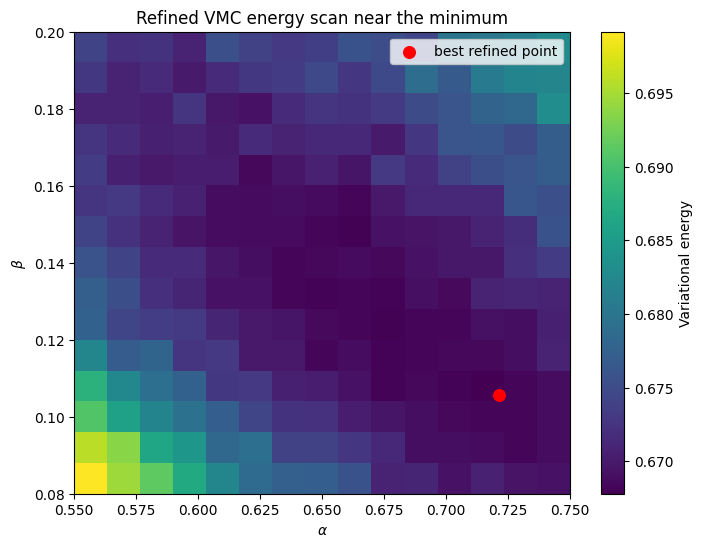

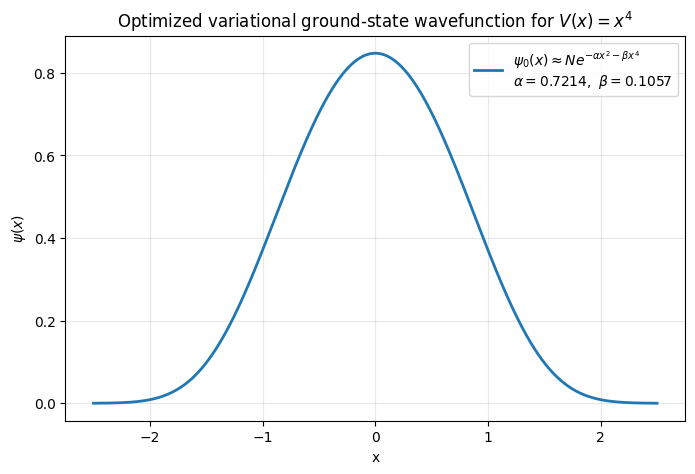

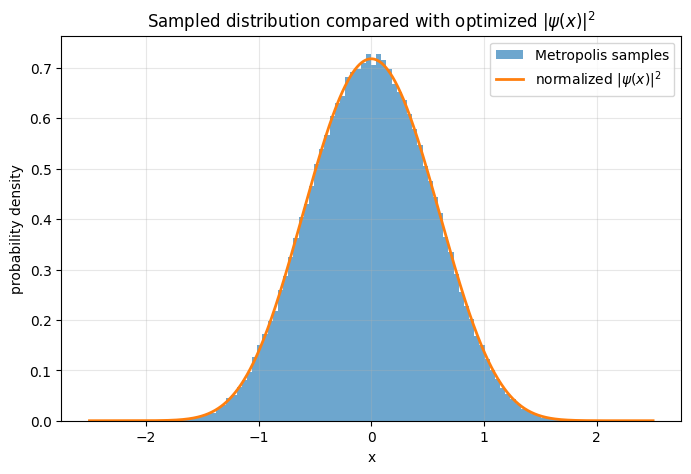

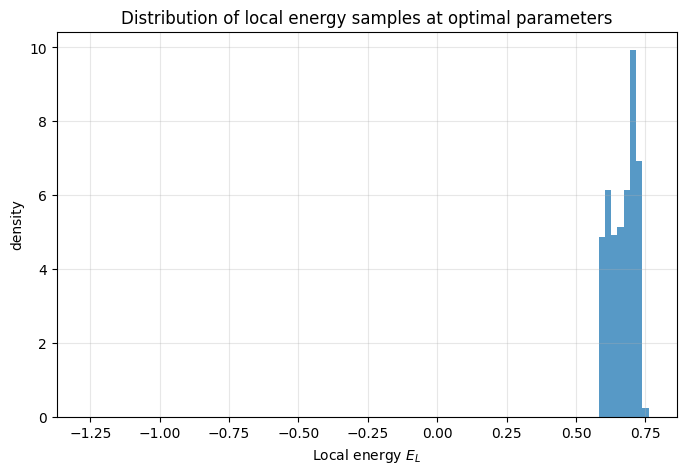


Numerical adequacy check at optimal parameters:
n_steps =  120000 : E = 0.66781654 +/- 0.00012760, acceptance = 0.724
n_steps =  300000 : E = 0.66816779 +/- 0.00008199, acceptance = 0.725
n_steps =  600000 : E = 0.66826416 +/- 0.00005657, acceptance = 0.724
n_steps =  900000 : E = 0.66840676 +/- 0.00004667, acceptance = 0.724

Comparison to previous 1-parameter Gaussian ansatz:
Old Gaussian VMC energy  ~ 0.68106667
New 2-parameter VMC energy = 0.66833843 +/- 0.00005660
Energy improvement         = 0.01272824


In [ ]:
# ============================================================
# PHYS 580 / Computational Physics
# Homework 7 - Problem 2
# Variational Monte Carlo for V(x) = x^4
#
# Improved 2-parameter trial wavefunction:
#   phi_{alpha,beta}(x) = exp(-alpha x^2 - beta x^4)
#
# Uses Metropolis sampling of p(x) ~ |phi(x)|^2
# to estimate the variational ground-state energy.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Random generator
# ------------------------------------------------------------
rng = np.random.default_rng(580)

# ------------------------------------------------------------
# Trial wavefunction and derived quantities
# ------------------------------------------------------------
def phi(x, alpha, beta):
    return np.exp(-alpha * x**2 - beta * x**4)

def prob_density_unnorm(x, alpha, beta):
    # proportional to |phi|^2
    return np.exp(-2.0 * alpha * x**2 - 2.0 * beta * x**4)

def local_energy(x, alpha, beta):
    """
    For phi = exp(-alpha x^2 - beta x^4),
    f(x) = alpha x^2 + beta x^4
    phi''/phi = f'^2 - f''
    E_L = -(1/2)(phi''/phi) + x^4

    This simplifies to:
    E_L = alpha + (6 beta - 2 alpha^2) x^2
              + (1 - 8 alpha beta) x^4
              - 8 beta^2 x^6
    """
    x2 = x*x
    x4 = x2*x2
    x6 = x4*x2
    return (
        alpha
        + (6.0*beta - 2.0*alpha**2)*x2
        + (1.0 - 8.0*alpha*beta)*x4
        - 8.0*beta**2*x6
    )

# ------------------------------------------------------------
# Metropolis sampler
# ------------------------------------------------------------
def metropolis_samples(alpha, beta, n_steps=200000, burn_in=20000,
                       step_size=1.0, x0=0.0, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    x = x0
    samples = []
    accepted = 0
    total = 0

    p_old = prob_density_unnorm(x, alpha, beta)

    for i in range(n_steps + burn_in):
        x_trial = x + rng.uniform(-step_size, step_size)
        p_new = prob_density_unnorm(x_trial, alpha, beta)

        if p_old == 0:
            A = 1.0
        else:
            A = min(1.0, p_new / p_old)

        if rng.random() < A:
            x = x_trial
            p_old = p_new
            if i >= burn_in:
                accepted += 1

        if i >= burn_in:
            samples.append(x)
            total += 1

    acceptance = accepted / total if total > 0 else 0.0
    return np.array(samples), acceptance

# ------------------------------------------------------------
# Estimate variational energy for one (alpha, beta)
# ------------------------------------------------------------
def vmc_energy(alpha, beta, n_steps=200000, burn_in=20000,
               step_size=1.0, rng=None):
    samples, acc = metropolis_samples(
        alpha=alpha,
        beta=beta,
        n_steps=n_steps,
        burn_in=burn_in,
        step_size=step_size,
        rng=rng
    )

    EL = local_energy(samples, alpha, beta)
    E_mean = np.mean(EL)
    E_std = np.std(EL, ddof=1)
    E_sem = E_std / np.sqrt(len(EL))

    return E_mean, E_sem, acc, samples, EL

# ------------------------------------------------------------
# Coarse 2D scan
# ------------------------------------------------------------
# Chosen to cover a sensible region near and beyond your old Gaussian optimum
alpha_grid = np.linspace(0.20, 1.00, 17)
beta_grid  = np.linspace(0.00, 0.30, 16)

E_grid = np.full((len(alpha_grid), len(beta_grid)), np.nan)
Err_grid = np.full_like(E_grid, np.nan, dtype=float)
Acc_grid = np.full_like(E_grid, np.nan, dtype=float)

print("Starting coarse 2D scan over (alpha, beta)...")
for i, alpha in enumerate(alpha_grid):
    for j, beta in enumerate(beta_grid):
        E_mean, E_sem, acc, _, _ = vmc_energy(
            alpha, beta,
            n_steps=80000,
            burn_in=10000,
            step_size=0.9,
            rng=rng
        )
        E_grid[i, j] = E_mean
        Err_grid[i, j] = E_sem
        Acc_grid[i, j] = acc

best_idx = np.unravel_index(np.argmin(E_grid), E_grid.shape)
alpha_best = alpha_grid[best_idx[0]]
beta_best  = beta_grid[best_idx[1]]
E_best_coarse = E_grid[best_idx]
E_best_coarse_err = Err_grid[best_idx]

print("\nBest coarse result:")
print(f"alpha_best = {alpha_best:.6f}")
print(f"beta_best  = {beta_best:.6f}")
print(f"E_best     = {E_best_coarse:.8f} +/- {E_best_coarse_err:.8f}")
print(f"acceptance = {Acc_grid[best_idx]:.3f}")

# ------------------------------------------------------------
# Refined 2D scan near the coarse minimum
# ------------------------------------------------------------
alpha_ref = np.linspace(max(0.05, alpha_best - 0.10), alpha_best + 0.10, 15)
beta_ref  = np.linspace(max(0.00, beta_best  - 0.06), beta_best  + 0.06, 15)

E_ref = np.full((len(alpha_ref), len(beta_ref)), np.nan)
Err_ref = np.full_like(E_ref, np.nan, dtype=float)
Acc_ref = np.full_like(E_ref, np.nan, dtype=float)

print("\nStarting refined 2D scan near the coarse minimum...")
for i, alpha in enumerate(alpha_ref):
    for j, beta in enumerate(beta_ref):
        E_mean, E_sem, acc, _, _ = vmc_energy(
            alpha, beta,
            n_steps=180000,
            burn_in=20000,
            step_size=0.8,
            rng=rng
        )
        E_ref[i, j] = E_mean
        Err_ref[i, j] = E_sem
        Acc_ref[i, j] = acc

best_ref_idx = np.unravel_index(np.argmin(E_ref), E_ref.shape)
alpha_opt = alpha_ref[best_ref_idx[0]]
beta_opt  = beta_ref[best_ref_idx[1]]
E_opt_scan = E_ref[best_ref_idx]
E_opt_scan_err = Err_ref[best_ref_idx]

print("\nBest refined result:")
print(f"alpha_opt(scan) = {alpha_opt:.8f}")
print(f"beta_opt(scan)  = {beta_opt:.8f}")
print(f"E_opt(scan)     = {E_opt_scan:.8f} +/- {E_opt_scan_err:.8f}")
print(f"acceptance      = {Acc_ref[best_ref_idx]:.3f}")

# ------------------------------------------------------------
# Final longer run at the optimized parameters
# ------------------------------------------------------------
E_opt, E_opt_err, acc_opt, samples_opt, EL_opt = vmc_energy(
    alpha_opt, beta_opt,
    n_steps=600000,
    burn_in=60000,
    step_size=0.8,
    rng=rng
)

print("\nFinal optimized result:")
print(f"alpha_opt = {alpha_opt:.8f}")
print(f"beta_opt  = {beta_opt:.8f}")
print(f"E0(VMC)   = {E_opt:.8f} +/- {E_opt_err:.8f}")
print(f"acceptance fraction = {acc_opt:.3f}")

# ------------------------------------------------------------
# Normalized optimized trial wavefunction
# ------------------------------------------------------------
# Numerical normalization because closed form is not as convenient now
def phi_norm(x, alpha, beta):
    psi = phi(x, alpha, beta)
    norm = np.sqrt(np.trapezoid(psi**2, x))
    return psi / norm

# ------------------------------------------------------------
# Plot 1: coarse energy heatmap
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))
im = plt.imshow(
    E_grid.T,
    origin='lower',
    aspect='auto',
    extent=[alpha_grid[0], alpha_grid[-1], beta_grid[0], beta_grid[-1]]
)
plt.colorbar(im, label='Variational energy')
plt.scatter([alpha_best], [beta_best], c='red', s=70, label='best coarse point')
plt.xlabel(r'$\alpha$')
plt.ylabel(r'$\beta$')
plt.title(r'Coarse VMC energy scan for $V(x)=x^4$')
plt.legend()
plt.show()

# ------------------------------------------------------------
# Plot 2: refined energy heatmap
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))
im = plt.imshow(
    E_ref.T,
    origin='lower',
    aspect='auto',
    extent=[alpha_ref[0], alpha_ref[-1], beta_ref[0], beta_ref[-1]]
)
plt.colorbar(im, label='Variational energy')
plt.scatter([alpha_opt], [beta_opt], c='red', s=70, label='best refined point')
plt.xlabel(r'$\alpha$')
plt.ylabel(r'$\beta$')
plt.title(r'Refined VMC energy scan near the minimum')
plt.legend()
plt.show()

# ------------------------------------------------------------
# Plot 3: optimized wavefunction
# ------------------------------------------------------------
x_plot = np.linspace(-2.5, 2.5, 1200)
psi_plot = phi_norm(x_plot, alpha_opt, beta_opt)

plt.figure(figsize=(8, 5))
plt.plot(
    x_plot, psi_plot, lw=2,
    label=fr'$\psi_0(x)\approx N e^{{-\alpha x^2-\beta x^4}}$' + "\n"
          + fr'$\alpha={alpha_opt:.4f},\ \beta={beta_opt:.4f}$'
)
plt.xlabel('x')
plt.ylabel(r'$\psi(x)$')
plt.title(r'Optimized variational ground-state wavefunction for $V(x)=x^4$')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# ------------------------------------------------------------
# Plot 4: sampled distribution vs optimized |psi|^2
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist(samples_opt, bins=90, density=True, alpha=0.65, label='Metropolis samples')

rho_plot = psi_plot**2
plt.plot(x_plot, rho_plot, lw=2, label=r'normalized $|\psi(x)|^2$')

plt.xlabel('x')
plt.ylabel('probability density')
plt.title(r'Sampled distribution compared with optimized $|\psi(x)|^2$')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# ------------------------------------------------------------
# Plot 5: local energy histogram
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist(EL_opt, bins=90, density=True, alpha=0.75)
plt.xlabel(r'Local energy $E_L$')
plt.ylabel('density')
plt.title('Distribution of local energy samples at optimal parameters')
plt.grid(alpha=0.3)
plt.show()

# ------------------------------------------------------------
# Numerical adequacy check: longer runs at optimum
# ------------------------------------------------------------
print("\nNumerical adequacy check at optimal parameters:")
for n_steps in [120000, 300000, 600000, 900000]:
    E_chk, E_chk_err, acc_chk, _, _ = vmc_energy(
        alpha_opt, beta_opt,
        n_steps=n_steps,
        burn_in=max(15000, n_steps // 10),
        step_size=0.8,
        rng=rng
    )
    print(
        f"n_steps = {n_steps:7d} : "
        f"E = {E_chk:.8f} +/- {E_chk_err:.8f}, acceptance = {acc_chk:.3f}"
    )

# ------------------------------------------------------------
# Compare with old 1-parameter Gaussian result if desired
# ------------------------------------------------------------
old_gaussian_energy = 0.68106667  # replace if you want with your exact previous value
print("\nComparison to previous 1-parameter Gaussian ansatz:")
print(f"Old Gaussian VMC energy  ~ {old_gaussian_energy:.8f}")
print(f"New 2-parameter VMC energy = {E_opt:.8f} +/- {E_opt_err:.8f}")
print(f"Energy improvement         = {old_gaussian_energy - E_opt:.8f}")

In [ ]:
# Problem 2 Snippets


# Trial wavefunction and derived quantities
def phi(x, alpha, beta):
    return np.exp(-alpha * x**2 - beta * x**4);

def prob_density_unnorm(x, alpha, beta):
    return np.exp(-2.0 * alpha * x**2 - 2.0 * beta * x**4);     # proportional to |phi|^2

# For phi = exp(-alpha x^2 - beta x^4), f(x) = alpha x^2 + beta x^4 phi''/phi = f'^2 - f'', E_L = -(1/2)(phi''/phi) + x^4
# This simplifies to: E_L = alpha + (6 beta - 2 alpha^2) x^2 + (1 - 8 alpha beta) x^4 - 8 beta^2 x^6
def local_energy(x, alpha, beta):
    x2 = x*x;
    x4 = x2*x2;
    x6 = x4*x2;
    return (alpha + (6.0*beta - 2.0*alpha**2)*x2 + (1.0 - 8.0*alpha*beta)*x4 - 8.0*beta**2*x6);


# Metropolis sampler
def metropolis_samples(alpha, beta, n_steps = 200000, burn_in = 20000, step_size = 1.0, x0 = 0.0, rng = None):
    if rng is None:
        rng = np.random.default_rng();
    x = x0;
    samples = [];
    accepted = 0;
    total = 0;
    p_old = prob_density_unnorm(x, alpha, beta);

    for i in range(n_steps + burn_in):
        x_trial = x + rng.uniform(-step_size, step_size);
        p_new = prob_density_unnorm(x_trial, alpha, beta);

        if p_old == 0:
            A = 1.0;
        else:
            A = min(1.0, p_new / p_old);

        if rng.random() < A:
            x = x_trial;
            p_old = p_new;
            if i >= burn_in:
                accepted += 1;

        if i >= burn_in:
            samples.append(x);
            total += 1;

    acceptance = accepted / total if total > 0 else 0.0;
    return np.array(samples), acceptance;


# Estimate variational energy for one (alpha, beta)
def vmc_energy(alpha, beta, n_steps = 200000, burn_in = 20000, step_size = 1.0, rng = None):
    samples, acc = metropolis_samples(alpha = alpha, beta = beta, n_steps = n_steps, burn_in = burn_in, step_size = step_size, rng = rng);
    EL = local_energy(samples, alpha, beta);
    E_mean = np.mean(EL);
    E_std = np.std(EL, ddof = 1);
    E_sem = E_std / np.sqrt(len(EL));

    return E_mean, E_sem, acc, samples, EL;


# Coarse 2D scan
alpha_grid = np.linspace(0.20, 1.00, 17);
beta_grid  = np.linspace(0.00, 0.30, 16);
E_grid = np.full((len(alpha_grid), len(beta_grid)), np.nan);
Err_grid = np.full_like(E_grid, np.nan, dtype = float);
Acc_grid = np.full_like(E_grid, np.nan, dtype = float);

print("Starting coarse 2D scan over (alpha, beta)...");
for i, alpha in enumerate(alpha_grid):
    for j, beta in enumerate(beta_grid):
        E_mean, E_sem, acc, _, _ = vmc_energy(alpha, beta, n_steps = 80000, burn_in = 10000, step_size = 0.9, rng = rng);
        E_grid[i, j] = E_mean;
        Err_grid[i, j] = E_sem;
        Acc_grid[i, j] = acc;
    #endfor
#endfor
best_idx = np.unravel_index(np.argmin(E_grid), E_grid.shape);
alpha_best = alpha_grid[best_idx[0]];
beta_best  = beta_grid[best_idx[1]];
E_best_coarse = E_grid[best_idx];
E_best_coarse_err = Err_grid[best_idx];

print("\nBest coarse result:");
print(f"alpha_best = {alpha_best:.6f}");
print(f"beta_best  = {beta_best:.6f}");
print(f"E_best     = {E_best_coarse:.8f} +/- {E_best_coarse_err:.8f}");
print(f"acceptance = {Acc_grid[best_idx]:.3f}");


# Refined 2D scan near the coarse minimum
alpha_ref = np.linspace(max(0.05, alpha_best - 0.10), alpha_best + 0.10, 15);
beta_ref  = np.linspace(max(0.00, beta_best  - 0.06), beta_best  + 0.06, 15);
E_ref = np.full((len(alpha_ref), len(beta_ref)), np.nan);
Err_ref = np.full_like(E_ref, np.nan, dtype = float);
Acc_ref = np.full_like(E_ref, np.nan, dtype = float);

print("\nStarting refined 2D scan near the coarse minimum...");
for i, alpha in enumerate(alpha_ref):
    for j, beta in enumerate(beta_ref):
        E_mean, E_sem, acc, _, _ = vmc_energy(alpha, beta, n_steps = 180000, burn_in = 20000, step_size = 0.8, rng = rng);
        E_ref[i, j] = E_mean;
        Err_ref[i, j] = E_sem;
        Acc_ref[i, j] = acc;
    #endfor
#endfor
best_ref_idx = np.unravel_index(np.argmin(E_ref), E_ref.shape);
alpha_opt = alpha_ref[best_ref_idx[0]];
beta_opt  = beta_ref[best_ref_idx[1]];
E_opt_scan = E_ref[best_ref_idx];
E_opt_scan_err = Err_ref[best_ref_idx];

print("\nBest refined result:");
print(f"alpha_opt(scan) = {alpha_opt:.8f}");
print(f"beta_opt(scan)  = {beta_opt:.8f}");
print(f"E_opt(scan)     = {E_opt_scan:.8f} +/- {E_opt_scan_err:.8f}");
print(f"acceptance      = {Acc_ref[best_ref_idx]:.3f}");


# Final longer run at the optimized parameters
E_opt, E_opt_err, acc_opt, samples_opt, EL_opt = vmc_energy(alpha_opt, beta_opt, n_steps = 600000, burn_in = 60000, step_size = 0.8,rng = rng);

print("\nFinal optimized result:");
print(f"alpha_opt = {alpha_opt:.8f}");
print(f"beta_opt  = {beta_opt:.8f}");
print(f"E0(VMC)   = {E_opt:.8f} +/- {E_opt_err:.8f}");
print(f"acceptance fraction = {acc_opt:.3f}");


# Numerical normalization because closed form is not as convenient now
def phi_norm(x, alpha, beta):
    psi = phi(x, alpha, beta);
    norm = np.sqrt(np.trapezoid(psi**2, x));
    return psi / norm;


Barrier height Vb = 4.0
  n=0, E=1.73277282, parity=even
  n=1, E=4.31734247, parity=odd
  n=2, E=10.37070819, parity=even
  n=3, E=17.21176369, parity=odd

Barrier height Vb = 8.0
  n=0, E=2.24076376, parity=even
  n=1, E=4.33699789, parity=odd
  n=2, E=11.09235947, parity=even
  n=3, E=17.28640056, parity=odd

Barrier height Vb = 16.0
  n=0, E=2.93956131, parity=even
  n=1, E=4.37338252, parity=odd
  n=2, E=12.44902811, parity=even
  n=3, E=17.42551776, parity=odd


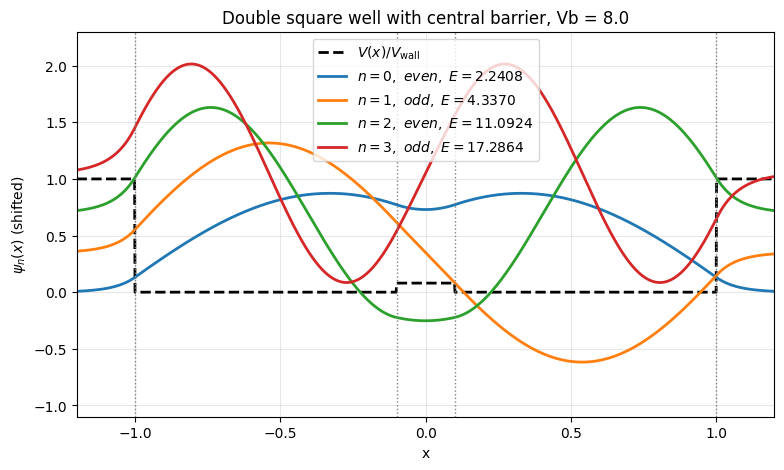

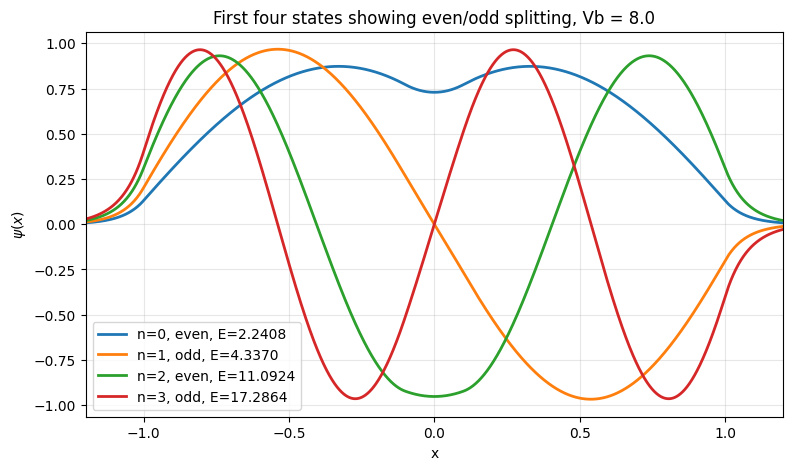

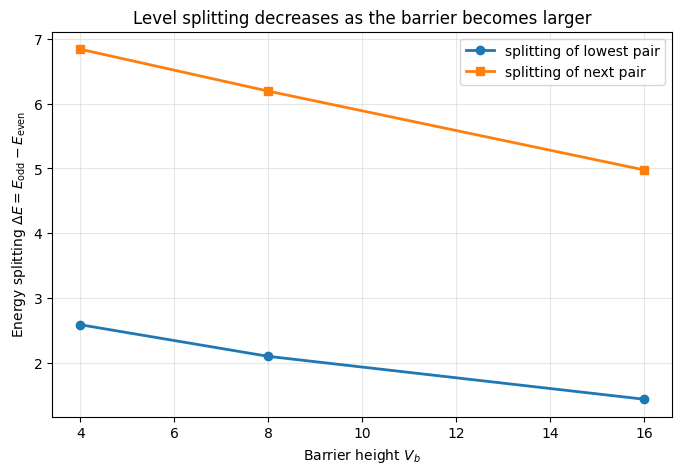

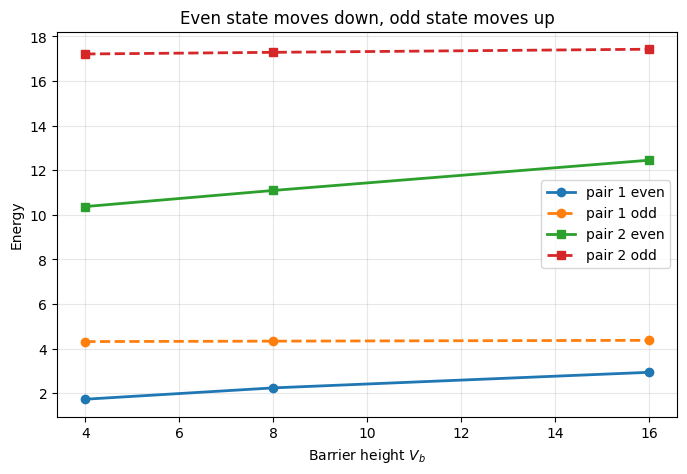


Numerical adequacy check for Vb = 8:

dx = 0.003
  n=0, E=2.23145828, parity=even
  n=1, E=4.34735934, parity=odd
  n=2, E=11.10044218, parity=even
  n=3, E=17.32773082, parity=odd

dx = 0.002
  n=0, E=2.23767561, parity=even
  n=1, E=4.34044802, parity=odd
  n=2, E=11.09506354, parity=even
  n=3, E=17.30017241, parity=odd

dx = 0.0015
  n=0, E=2.24076376, parity=even
  n=1, E=4.33699789, parity=odd
  n=2, E=11.09235947, parity=even
  n=3, E=17.28640056, parity=odd


In [ ]:
# ============================================================
# PHYS 580 / Computational Physics
# Homework 7 - Problem 3
# Matching method for two coupled square wells separated
# by a central square barrier
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# ------------------------------------------------------------
# Potential: symmetric double square well with central barrier
# ------------------------------------------------------------
def V_double_well(x, Vb=8.0, b=0.10, L=1.0, Vwall=100.0):
    x = np.asarray(x)
    V = np.zeros_like(x, dtype=float)
    V[np.abs(x) >= L] = Vwall
    V[np.abs(x) <= b] = Vb
    return V

# ------------------------------------------------------------
# Numerov-like / Verlet recurrence for TISE
# psi_{n+1} = 2 psi_n - psi_{n-1} - 2 dx^2 (E - V_n) psi_n
# ------------------------------------------------------------
def integrate_left(E, x, V):
    dx = x[1] - x[0]
    N = len(x)

    psi = np.zeros(N)
    psi[0] = 0.0
    psi[1] = 1e-8

    for i in range(1, N - 1):
        psi[i+1] = 2*psi[i] - psi[i-1] - 2*dx*dx*(E - V[i])*psi[i]

        if abs(psi[i+1]) > 1e100:
            psi[i+1:] = np.nan
            break

    return psi

def integrate_right(E, x, V):
    dx = x[1] - x[0]
    N = len(x)

    psi = np.zeros(N)
    psi[-1] = 0.0
    psi[-2] = 1e-8

    for i in range(N-2, 0, -1):
        psi[i-1] = 2*psi[i] - psi[i+1] - 2*dx*dx*(E - V[i])*psi[i]

        if abs(psi[i-1]) > 1e100:
            psi[:i-1] = np.nan
            break

    return psi

# ------------------------------------------------------------
# Matching residual: compare logarithmic derivatives at midpoint
# ------------------------------------------------------------
def match_residual(E, x, V, match_index):
    dx = x[1] - x[0]

    psiL = integrate_left(E, x, V)
    psiR = integrate_right(E, x, V)

    if not np.all(np.isfinite(psiL)) or not np.all(np.isfinite(psiR)):
        return np.nan

    # rescale right solution so values match at midpoint
    if abs(psiR[match_index]) < 1e-14:
        return np.nan

    scale = psiL[match_index] / psiR[match_index]
    psiR = scale * psiR

    # compare derivatives at match point
    dL = (psiL[match_index + 1] - psiL[match_index - 1]) / (2*dx)
    dR = (psiR[match_index + 1] - psiR[match_index - 1]) / (2*dx)

    return dL - dR

# ------------------------------------------------------------
# Build matched full wavefunction
# ------------------------------------------------------------
def matched_wavefunction(E, x, V, match_index):
    psiL = integrate_left(E, x, V)
    psiR = integrate_right(E, x, V)

    scale = psiL[match_index] / psiR[match_index]
    psiR = scale * psiR

    psi = np.empty_like(x)
    psi[:match_index+1] = psiL[:match_index+1]
    psi[match_index+1:] = psiR[match_index+1:]

    # normalize
    norm = np.sqrt(np.trapezoid(psi**2, x))
    psi /= norm
    return psi

# ------------------------------------------------------------
# Find eigenvalues by scanning energy and locating sign changes
# ------------------------------------------------------------
def find_eigenvalues(x, V, E_min=0.0, E_max=20.0, nscan=2000):
    match_index = len(x) // 2
    Egrid = np.linspace(E_min, E_max, nscan)
    F = np.array([match_residual(E, x, V, match_index) for E in Egrid])

    roots = []
    for i in range(nscan - 1):
        f1, f2 = F[i], F[i+1]
        if not np.isfinite(f1) or not np.isfinite(f2):
            continue
        if f1 == 0 or f1 * f2 < 0:
            try:
                root = brentq(lambda E: match_residual(E, x, V, match_index),
                              Egrid[i], Egrid[i+1], xtol=1e-12, rtol=1e-12)
                if len(roots) == 0 or abs(root - roots[-1]) > 1e-5:
                    roots.append(root)
            except ValueError:
                pass
    return roots

# ------------------------------------------------------------
# Determine parity approximately
# ------------------------------------------------------------
def estimate_parity(x, psi):
    psi_mirror = psi[::-1]
    even_err = np.max(np.abs(psi - psi_mirror))
    odd_err  = np.max(np.abs(psi + psi_mirror))
    return "even" if even_err < odd_err else "odd"

# ------------------------------------------------------------
# Main study parameters
# ------------------------------------------------------------
L = 1.0
b = 0.10
Vwall = 100.0
dx = 0.0015
x = np.arange(-1.3, 1.3 + dx, dx)

Vb_values = [4.0, 8.0, 16.0]

results = {}

# ------------------------------------------------------------
# Solve for each barrier height
# ------------------------------------------------------------
for Vb in Vb_values:
    V = V_double_well(x, Vb=Vb, b=b, L=L, Vwall=Vwall)
    eigs = find_eigenvalues(x, V, E_min=0.0, E_max=20.0, nscan=2500)

    states = []
    for E in eigs[:6]:
        psi = matched_wavefunction(E, x, V, len(x)//2)
        parity = estimate_parity(x, psi)
        states.append((E, parity, psi))

    states.sort(key=lambda item: item[0])
    results[Vb] = states

# ------------------------------------------------------------
# Print energies
# ------------------------------------------------------------
for Vb in Vb_values:
    print(f"\nBarrier height Vb = {Vb}")
    for n, (E, parity, psi) in enumerate(results[Vb]):
        print(f"  n={n}, E={E:.8f}, parity={parity}")

# ------------------------------------------------------------
# Plot 1: representative potential and first four states
# ------------------------------------------------------------
Vb_rep = 8.0
Vrep = V_double_well(x, Vb=Vb_rep, b=b, L=L, Vwall=Vwall)
states_rep = results[Vb_rep]

plt.figure(figsize=(9, 5))
plt.plot(x, Vrep / Vwall, 'k--', lw=2, label=r'$V(x)/V_{\rm wall}$')

for n, (E, parity, psi) in enumerate(states_rep[:4]):
    plt.plot(x, psi + 0.35*n, lw=2,
             label=fr'$n={n},\ {parity},\ E={E:.4f}$')

plt.axvline(-L, color='gray', ls=':', lw=1)
plt.axvline(-b, color='gray', ls=':', lw=1)
plt.axvline( b, color='gray', ls=':', lw=1)
plt.axvline( L, color='gray', ls=':', lw=1)

plt.xlim(-1.2, 1.2)
plt.ylim(-1.1, 2.3)
plt.xlabel('x')
plt.ylabel(r'$\psi_n(x)$ (shifted)')
plt.title(f'Double square well with central barrier, Vb = {Vb_rep}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ------------------------------------------------------------
# Plot 2: show the first two split pairs for a representative case
# ------------------------------------------------------------
plt.figure(figsize=(9, 5))
for n, idx in enumerate([0, 1, 2, 3]):
    E, parity, psi = states_rep[idx]
    plt.plot(x, psi, lw=2, label=fr'n={idx}, {parity}, E={E:.4f}')
plt.xlim(-1.2, 1.2)
plt.xlabel('x')
plt.ylabel(r'$\psi(x)$')
plt.title(f'First four states showing even/odd splitting, Vb = {Vb_rep}')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# ------------------------------------------------------------
# Extract splittings for first two pairs
# pair 1: states 0 and 1
# pair 2: states 2 and 3
# ------------------------------------------------------------
Vb_plot = []
split_1 = []
split_2 = []
E_even_1 = []
E_odd_1 = []
E_even_2 = []
E_odd_2 = []

for Vb in Vb_values:
    states = results[Vb]
    if len(states) >= 4:
        # sort each pair by parity
        pair1 = states[:2]
        pair2 = states[2:4]

        E1e = [E for E,p,psi in pair1 if p == 'even'][0]
        E1o = [E for E,p,psi in pair1 if p == 'odd'][0]
        E2e = [E for E,p,psi in pair2 if p == 'even'][0]
        E2o = [E for E,p,psi in pair2 if p == 'odd'][0]

        Vb_plot.append(Vb)
        E_even_1.append(E1e)
        E_odd_1.append(E1o)
        E_even_2.append(E2e)
        E_odd_2.append(E2o)
        split_1.append(E1o - E1e)
        split_2.append(E2o - E2e)

# ------------------------------------------------------------
# Plot 3: splitting vs barrier height
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(Vb_plot, split_1, 'o-', lw=2, label='splitting of lowest pair')
plt.plot(Vb_plot, split_2, 's-', lw=2, label='splitting of next pair')
plt.xlabel(r'Barrier height $V_b$')
plt.ylabel(r'Energy splitting $\Delta E = E_{\rm odd}-E_{\rm even}$')
plt.title('Level splitting decreases as the barrier becomes larger')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# ------------------------------------------------------------
# Plot 4: even and odd energies for the first two pairs
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(Vb_plot, E_even_1, 'o-', lw=2, label='pair 1 even')
plt.plot(Vb_plot, E_odd_1,  'o--', lw=2, label='pair 1 odd')
plt.plot(Vb_plot, E_even_2, 's-', lw=2, label='pair 2 even')
plt.plot(Vb_plot, E_odd_2,  's--', lw=2, label='pair 2 odd')
plt.xlabel(r'Barrier height $V_b$')
plt.ylabel('Energy')
plt.title('Even state moves down, odd state moves up')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# ------------------------------------------------------------
# Numerical adequacy check for one representative case
# ------------------------------------------------------------
print("\nNumerical adequacy check for Vb = 8:")
for dx_test in [0.0030, 0.0020, 0.0015]:
    x_test = np.arange(-1.3, 1.3 + dx_test, dx_test)
    V_test = V_double_well(x_test, Vb=8.0, b=b, L=L, Vwall=Vwall)
    eigs_test = find_eigenvalues(x_test, V_test, E_min=0.0, E_max=20.0, nscan=2200)

    states_test = []
    for E in eigs_test[:4]:
        psi = matched_wavefunction(E, x_test, V_test, len(x_test)//2)
        parity = estimate_parity(x_test, psi)
        states_test.append((E, parity))

    states_test.sort(key=lambda item: item[0])
    print(f"\ndx = {dx_test}")
    for n, (E, parity) in enumerate(states_test):
        print(f"  n={n}, E={E:.8f}, parity={parity}")

In [ ]:
# Problem 3 Snippets

# Potential - symmetric double square well with central barrier
def V_double_well(x, Vb = 8.0, b = 0.10, L = 1.0, Vwall = 100.0):
    x = np.asarray(x);
    V = np.zeros_like(x, dtype = float);
    V[np.abs(x) >= L] = Vwall;
    V[np.abs(x) <= b] = Vb;
    return V;

# Verlet recurrence for  the time-independent Schrödinger equation
def integrate_left(E, x, V):
    dx = x[1] - x[0];
    N = len(x);
    psi = np.zeros(N);
    psi[0] = 0.0;
    psi[1] = 1e-8;
    for i in range(1, N - 1):
        psi[i+1] = 2*psi[i] - psi[i-1] - 2*dx*dx*(E - V[i])*psi[i];

        if abs(psi[i+1]) > 1e100:
            psi[i+1:] = np.nan;
            break;

    return psi;

# Other way
def integrate_right(E, x, V):
    dx = x[1] - x[0];
    N = len(x);
    psi = np.zeros(N);
    psi[-1] = 0.0;
    psi[-2] = 1e-8;
    for i in range(N-2, 0, -1):
        psi[i-1] = 2*psi[i] - psi[i+1] - 2*dx*dx*(E - V[i])*psi[i];

        if abs(psi[i-1]) > 1e100:
            psi[:i-1] = np.nan;
            break;

    return psi;

# Compare logarithmic derivatives at midpoint
def match_residual(E, x, V, match_index):
    dx = x[1] - x[0];
    psiL = integrate_left(E, x, V);
    psiR = integrate_right(E, x, V);
    if not np.all(np.isfinite(psiL)) or not np.all(np.isfinite(psiR)):
        return np.nan;
    # rescale right solution so values match at midpoint
    if abs(psiR[match_index]) < 1e-14:
        return np.nan;

    scale = psiL[match_index] / psiR[match_index];
    psiR = scale * psiR;
    # compare derivatives at match point
    dL = (psiL[match_index + 1] - psiL[match_index - 1]) / (2*dx);
    dR = (psiR[match_index + 1] - psiR[match_index - 1]) / (2*dx);

    return dL - dR;

# Build matched full wavefunction
def matched_wavefunction(E, x, V, match_index):
    psiL = integrate_left(E, x, V);
    psiR = integrate_right(E, x, V);
    scale = psiL[match_index] / psiR[match_index];
    psiR = scale * psiR;
    psi = np.empty_like(x);
    psi[:match_index + 1] = psiL[:match_index + 1];
    psi[match_index + 1:] = psiR[match_index + 1:];
    # normalize
    norm = np.sqrt(np.trapezoid(psi**2, x));
    psi /= norm;

    return psi;


# Find eigenvalues by scanning energy and locating sign changes
def find_eigenvalues(x, V, E_min = 0.0, E_max = 20.0, nscan = 2000):
    match_index = len(x) // 2;
    Egrid = np.linspace(E_min, E_max, nscan);
    F = np.array([match_residual(E, x, V, match_index) for E in Egrid]);
    roots = [];
    for i in range(nscan - 1):
        f1, f2 = F[i], F[i + 1];
        if not np.isfinite(f1) or not np.isfinite(f2):
            continue;
        if f1 == 0 or f1 * f2 < 0:
            try:
                root = brentq(lambda E: match_residual(E, x, V, match_index), Egrid[i], Egrid[i+1], xtol = 1e-12, rtol = 1e-12);
                if len(roots) == 0 or abs(root - roots[-1]) > 1e-5:
                    roots.append(root);
            except ValueError:
                pass;
    return roots;


# Determine parity approximately
def estimate_parity(x, psi):
    psi_mirror = psi[::-1];
    even_err = np.max(np.abs(psi - psi_mirror));
    odd_err  = np.max(np.abs(psi + psi_mirror));
    return "even" if even_err < odd_err else "odd";
